# Chapters 4 and 5: Hypothesis Testing


In this notebook, we use Python to build intuition for hypothesis testing.

We will focus on:
- the null and alternative hypotheses
- sampling variability
- p-values
- significance level
- z-scores and t-scores
- one-tailed and two-tailed tests
- a complete cereal-box example


# Chapter 4: Hypothesis Testing — Seeing the Story in the Data

## The Cereal Box Example

In [15]:
# The company claims that the average cereal box weight is 500 grams

claimed_mean <- 500

# A quality-control analyst collects a sample of 40 boxes
# and finds that the sample mean is 496 grams

sample_mean <- 496
sample_size <- 40

cat("Claimed mean:", claimed_mean, "\n")
cat("Sample mean:", sample_mean, "\n")
cat("Sample size:", sample_size, "\n")

Claimed mean: 500 
Sample mean: 496 
Sample size: 40 


## Two Competing Stories

In [16]:
# Null hypothesis:
# H0: the true average box weight is 500 grams

# Alternative hypothesis:
# Ha: the true average box weight is less than 500 grams

cat("H0: mu = 500\n")
cat("Ha: mu < 500\n")

H0: mu = 500
Ha: mu < 500


## Sampling Variability

In [17]:
# Even if the true mean is 500 grams,
# different samples can produce different sample means.

set.seed(42)

population <- rnorm(n = 10000, mean = 500, sd = 8)

In [18]:
# Take three random samples from the same population

sample_1 <- sample(population, size = 40)
sample_2 <- sample(population, size = 40)
sample_3 <- sample(population, size = 40)

cat("Sample 1 mean:", round(mean(sample_1), 2), "\n")
cat("Sample 2 mean:", round(mean(sample_2), 2), "\n")
cat("Sample 3 mean:", round(mean(sample_3), 2), "\n")

Sample 1 mean: 498.56 
Sample 2 mean: 498.85 
Sample 3 mean: 500.89 


## Sampling Distribution Under the Null Hypothesis

In [19]:
# Store sample means

sample_means <- c()

In [20]:
# Generate many sample means assuming H0 is true

for (i in 1:1000) {
  sample_values <- sample(population, size = 40)
  sample_means <- c(sample_means, mean(sample_values))
}

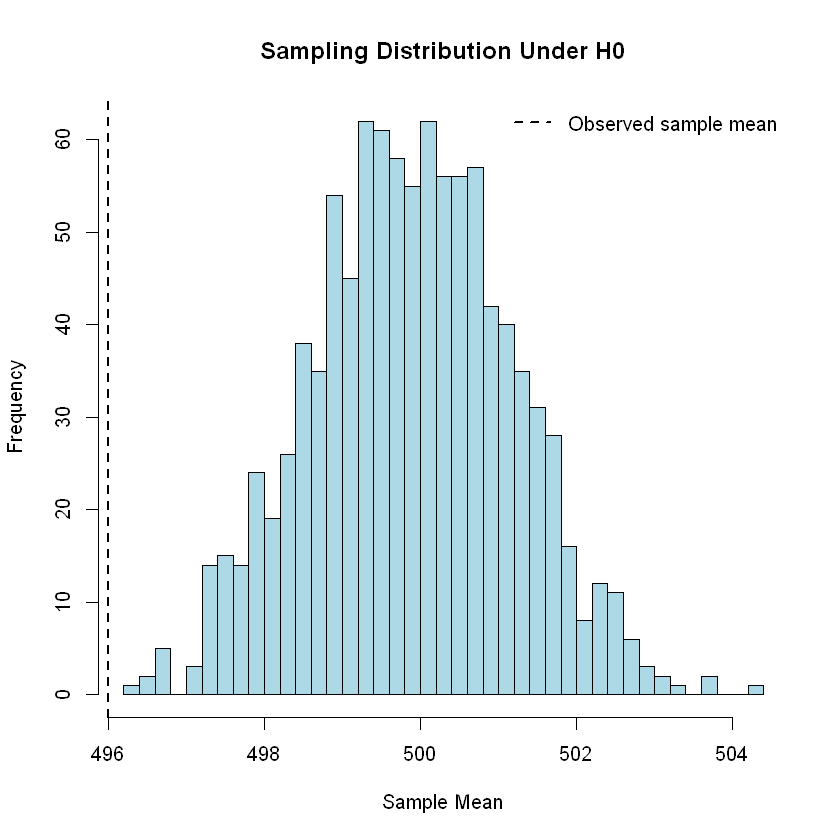

In [21]:
# Visualize the sampling distribution

hist(
  sample_means,
  breaks = 30,
  main = "Sampling Distribution Under H0",
  xlab = "Sample Mean",
  ylab = "Frequency",
  col = "lightblue"
)

abline(v = 496, lty = 2, lwd = 2)

legend(
  "topright",
  legend = "Observed sample mean",
  lty = 2,
  lwd = 2,
  bty = "n"
)

## The p-Value Idea

In [22]:
# A p-value asks:
# If H0 were true, how likely would it be to see
# a result as extreme as the one we observed?

population_mean <- 500
population_std <- 8
sample_size <- 40
observed_mean <- 496

standard_error <- population_std / sqrt(sample_size)

z_score <- (observed_mean - population_mean) / standard_error

p_value <- pnorm(z_score)

cat("Standard error:", round(standard_error, 2), "\n")
cat("Z-score:", round(z_score, 2), "\n")
cat("P-value:", round(p_value, 4), "\n")

Standard error: 1.26 
Z-score: -3.16 
P-value: 8e-04 


## Significance Level

In [23]:
# The significance level is the cutoff we use
# to decide whether the result is rare enough.

alpha <- 0.05

if (p_value < alpha) {
  cat("Reject H0\n")
} else {
  cat("Fail to reject H0\n")
}

Reject H0


## Dice Example: Rare Events

In [24]:
# Probability of getting ten sixes in a row
# when rolling a fair die

probability <- (1 / 6) ^ 10

cat("Probability:", probability, "\n")

Probability: 1.653817e-08 


## Binomial Example: Number of Sixes in 10 Rolls

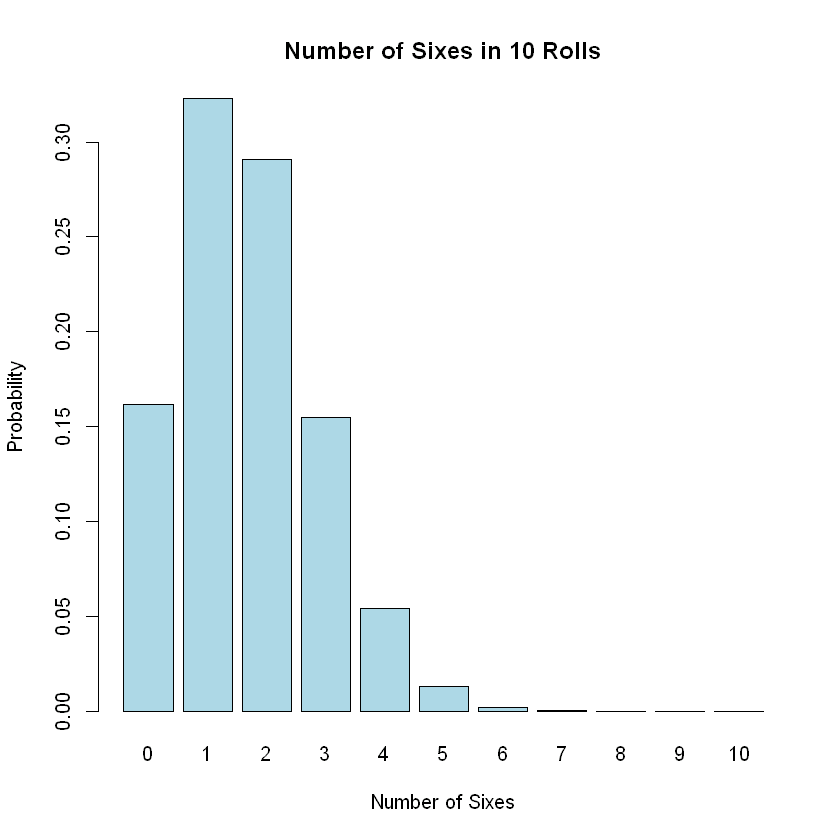

In [25]:
# Possible number of sixes in 10 rolls

x <- 0:10

# Probability of each outcome under a fair die

y <- dbinom(x, size = 10, prob = 1 / 6)

barplot(
  y,
  names.arg = x,
  main = "Number of Sixes in 10 Rolls",
  xlab = "Number of Sixes",
  ylab = "Probability",
  col = "lightblue"
)

## Two-Tailed Thinking

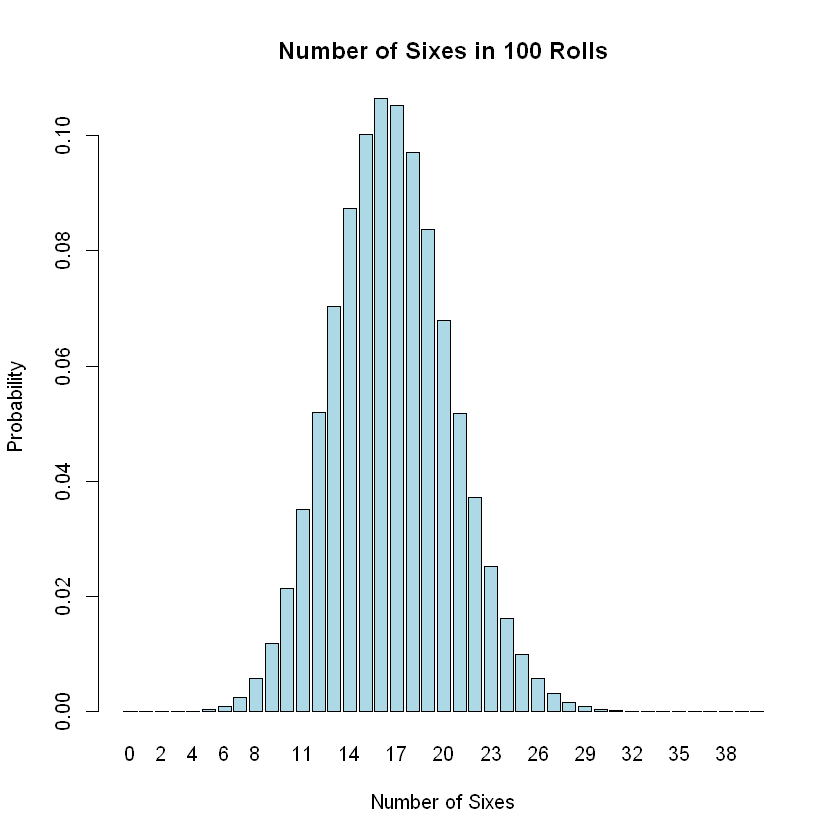

In [26]:
# For a larger number of rolls,
# unusually low and unusually high values can both be suspicious.

x <- 0:40

y <- dbinom(x, size = 100, prob = 1 / 6)

barplot(
  y,
  names.arg = x,
  main = "Number of Sixes in 100 Rolls",
  xlab = "Number of Sixes",
  ylab = "Probability",
  col = "lightblue"
)

# Chapter 5: From Intuition to Measurement

## Standardizing Differences

In [27]:
# A raw difference becomes meaningful
# only when compared to the standard error.

observed_difference <- sample_mean - claimed_mean

standard_error <- 8 / sqrt(64)

standardized_difference <- observed_difference / standard_error

cat("Observed difference:", observed_difference, "\n")
cat("Standard error:", standard_error, "\n")
cat("Standardized difference:", standardized_difference, "\n")

Observed difference: -4 
Standard error: 1 
Standardized difference: -4 


## z-Score Example

In [28]:
# Cereal box example with known population standard deviation

mu_0 <- 500
sigma <- 8
n <- 64
x_bar <- 496

standard_error <- sigma / sqrt(n)

z_score <- (x_bar - mu_0) / standard_error

cat("Standard error:", standard_error, "\n")
cat("Z-score:", z_score, "\n")

Standard error: 1 
Z-score: -4 


## From z-Score to p-Value

In [29]:
# Left-tailed p-value

p_value <- pnorm(z_score)

cat("P-value:", round(p_value, 5), "\n")

P-value: 3e-05 


## t-Score Example

In [30]:
# In practice, we often do not know the population standard deviation.
# Then we use the sample standard deviation and a t-score.

mu_0 <- 500
x_bar <- 496
s <- 8
n <- 25

standard_error <- s / sqrt(n)

t_score <- (x_bar - mu_0) / standard_error

cat("Standard error:", standard_error, "\n")
cat("t-score:", t_score, "\n")

Standard error: 1.6 
t-score: -2.5 


## Degrees of Freedom

In [31]:
# Degrees of freedom for a one-sample t-test

df <- n - 1

cat("Degrees of freedom:", df, "\n")

Degrees of freedom: 24 


## Left-Tailed t-Test

In [32]:
# Left-tailed p-value:
# probability of observing a t-score this low or lower

p_value_left <- pt(t_score, df = df)

cat("Left-tailed p-value:", round(p_value_left, 4), "\n")

Left-tailed p-value: 0.0098 


In [33]:
alpha <- 0.05

if (p_value_left < alpha) {
  cat("Reject H0\n")
} else {
  cat("Fail to reject H0\n")
}

Reject H0


## Right-Tailed t-Test

In [34]:
# Suppose the analyst is worried about overfilling

mu_0 <- 500
x_bar <- 502
s <- 8
n <- 25

standard_error <- s / sqrt(n)

t_score <- (x_bar - mu_0) / standard_error

df <- n - 1

p_value_right <- 1 - pt(t_score, df = df)

cat("t-score:", round(t_score, 2), "\n")
cat("Right-tailed p-value:", round(p_value_right, 4), "\n")

t-score: 1.25 
Right-tailed p-value: 0.1117 


In [35]:
alpha <- 0.05

if (p_value_right < alpha) {
  cat("Reject H0\n")
} else {
  cat("Fail to reject H0\n")
}

Fail to reject H0


## Two-Tailed t-Test

In [36]:
# In a two-tailed test, we care about differences in either direction.

mu_0 <- 500
x_bar <- 496
s <- 8
n <- 25

standard_error <- s / sqrt(n)

t_score <- (x_bar - mu_0) / standard_error

df <- n - 1

p_value_two <- 2 * pt(t_score, df = df)

cat("t-score:", round(t_score, 2), "\n")
cat("Two-tailed p-value:", round(p_value_two, 4), "\n")

t-score: -2.5 
Two-tailed p-value: 0.0197 


## Visualizing the t-Distribution

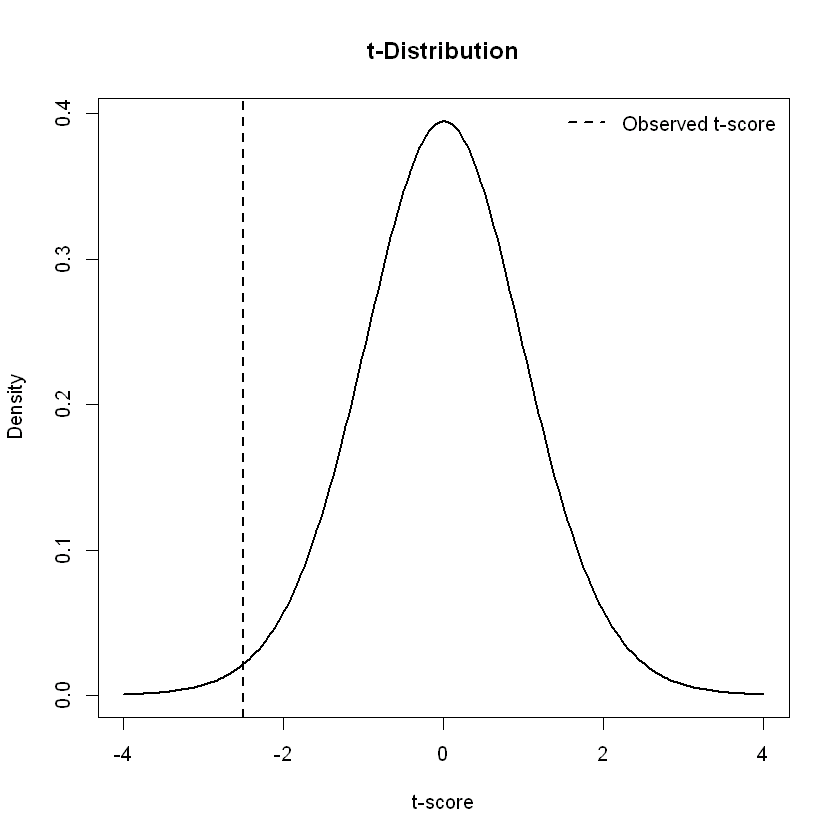

In [37]:
# Create values for the horizontal axis

x <- seq(-4, 4, length.out = 200)

# Calculate the t-distribution density

y <- dt(x, df = 24)

plot(
  x, y,
  type = "l",
  main = "t-Distribution",
  xlab = "t-score",
  ylab = "Density",
  lwd = 2
)

abline(v = t_score, lty = 2, lwd = 2)

legend(
  "topright",
  legend = "Observed t-score",
  lty = 2,
  lwd = 2,
  bty = "n"
)

## Practice Example: Coffee Temperature

In [38]:
# A café promises an average serving temperature of 70°C.
# A sample of 25 drinks has mean 68.9 and standard deviation 2.5.

mu_0 <- 70
x_bar <- 68.9
s <- 2.5
n <- 25

standard_error <- s / sqrt(n)

t_score <- (x_bar - mu_0) / standard_error

df <- n - 1

# Two-tailed p-value

p_value <- 2 * pt(t_score, df = df)

cat("t-score:", round(t_score, 2), "\n")
cat("p-value:", round(p_value, 4), "\n")

t-score: -2.2 
p-value: 0.0377 


In [39]:
alpha <- 0.05

if (p_value < alpha) {
  cat("Reject H0\n")
} else {
  cat("Fail to reject H0\n")
}

Reject H0


## Practice Example: Wind Turbine Efficiency

In [40]:
# A turbine is expected to produce 2.5 MW.
# A sample of 20 operating periods has mean 2.31 and standard deviation 0.42.

mu_0 <- 2.5
x_bar <- 2.31
s <- 0.42
n <- 20

standard_error <- s / sqrt(n)

t_score <- (x_bar - mu_0) / standard_error

df <- n - 1

# Left-tailed p-value

p_value <- pt(t_score, df = df)

cat("t-score:", round(t_score, 2), "\n")
cat("p-value:", round(p_value, 4), "\n")

t-score: -2.02 
p-value: 0.0287 


In [41]:
alpha <- 0.05

if (p_value < alpha) {
  cat("Reject H0\n")
} else {
  cat("Fail to reject H0\n")
}

Reject H0


## Practice Example: Battery Lifetime Improvement

In [42]:
# A battery is expected to last 10 hours.
# A sample of 30 batteries has mean 10.8 and standard deviation 2.1.

mu_0 <- 10
x_bar <- 10.8
s <- 2.1
n <- 30

standard_error <- s / sqrt(n)

t_score <- (x_bar - mu_0) / standard_error

df <- n - 1

# Right-tailed p-value

p_value <- 1 - pt(t_score, df = df)

cat("t-score:", round(t_score, 2), "\n")
cat("p-value:", round(p_value, 4), "\n")

t-score: 2.09 
p-value: 0.0229 


In [43]:
alpha <- 0.05

if (p_value < alpha) {
  cat("Reject H0\n")
} else {
  cat("Fail to reject H0\n")
}

Reject H0
